In [28]:
library(dplyr)
library(ggplot2)
setwd("/srv/home/mlef0011/Phasomix")
options(repr.plot.width = 8, repr.plot.height = 8)


SE_RATES <- c(0,
  1/1000,  # 0.001  (0.1%)
  1/500,   # 0.002  (0.2%)
  1/200,   # 0.005  (0.5%)
  1/100    # 0.01   (1%)
)

chr_sizes <- data.frame(
  chr = 1:22,
  chr_length = c(
    249250621, 243199373, 198022430, 191154276, 180915260, 171115067,
    159138663, 146364022, 141213431, 135534747, 135006516, 133851895,
    115169878, 107349540, 102531392,  90354753,  81195210,  78077248,
     59128983,  63025520,  48129895,  51304566
  )
)

# ── Setup commun ────────────────────────────────────────────────────────────
pop_info <- read.table("rawdata/1kGp/info/1kGP.3202_samples.pop_info.txt",
                       sep = "\t", header = TRUE)
pops <- setdiff(unique(na.omit(pop_info$Super.Population)), "AMR")
subpops <- setNames(lapply(pops, function(p)
  na.omit(unique(pop_info[pop_info$Super.Population == p, "Population"]))), pops)
                           


# ── Fonction : un df d'accuracy par simulation, paramétré par le nom global ──
build_accuracy_df <- function(global_name) {
  ancestry_combs <- c(setNames(list(pops), global_name), subpops)
  rows <- lapply(SE_RATES, function(SE) {
    lapply(seq_along(ancestry_combs), function(i) {
      ancestry_comb <- names(ancestry_combs[i])
      ancestries    <- sort(ancestry_combs[[i]])
      if (length(ancestries) < 2) return(NULL)
      path <- paste0("output/local_ancestry/accuracy/accuracy_gnomix_simulations_mixed_ancestry_SE_",
                     round(SE, 5), "_", ancestry_comb, ".tsv")
      if (!file.exists(path)) return(NULL)
      af <- read.table(path, header = TRUE, sep = "\t")
      af <- af[af$chr %in% 22:22, ]
      w  <- chr_sizes$chr_length[match(af$chr, chr_sizes$chr)]
      pairs <- combn(ancestries, 2, FUN = function(x) paste(x, collapse = "."))
      do.call(rbind, lapply(pairs, function(comb) {
        mask <- grepl(comb, colnames(af), fixed = TRUE)
        if (!any(mask)) return(NULL)
        sim <- af[, mask, drop = FALSE]
        data.frame(
          SE        = paste0("SER = ", round(SE * 100, 5), "%"),
          pop       = ancestry_comb,
          comb      = comb,
          replicate = colnames(sim),
          accuracy  = apply(sim, 2, weighted.mean, w = w, na.rm = TRUE),
          stringsAsFactors = FALSE
        )
      }))
    })
  })
  do.call(rbind, unlist(rows, recursive = FALSE))
}

In [29]:
accuracy_df_AMR    <- build_accuracy_df("POP")
accuracy_df_no_AMR <- build_accuracy_df("POP_no_AMR")
accuracy_df_no_AMR_no_balanced <- build_accuracy_df("POP_no_balanced_no_AMR")

In [63]:
library(dplyr)
library(ggplot2)
setwd("/srv/home/mlef0011/Phasomix")
options(repr.plot.width = 8, repr.plot.height = 8)


SE_RATES <- c(0,
  1/1000,  # 0.001  (0.1%)
  1/500,   # 0.002  (0.2%)
  1/200,   # 0.005  (0.5%)
  1/100    # 0.01   (1%)
)

chr_sizes <- data.frame(
  chr = 1:22,
  chr_length = c(
    249250621, 243199373, 198022430, 191154276, 180915260, 171115067,
    159138663, 146364022, 141213431, 135534747, 135006516, 133851895,
    115169878, 107349540, 102531392,  90354753,  81195210,  78077248,
     59128983,  63025520,  48129895,  51304566
  )
)

# ── Setup commun ────────────────────────────────────────────────────────────
pop_info <- read.table("rawdata/1kGp/info/1kGP.3202_samples.pop_info.txt",
                       sep = "\t", header = TRUE)
pops <- setdiff(unique(na.omit(pop_info$Super.Population)), "AMR")
subpops <- setNames(lapply(pops, function(p)
  na.omit(unique(pop_info[pop_info$Super.Population == p, "Population"]))), pops)
                           


# ── Fonction : un df d'accuracy par simulation, paramétré par le nom global ──
build_accuracy_df <- function(global_name) {
  ancestry_combs <- c(setNames(list(pops), global_name), subpops)
  rows <- lapply(SE_RATES, function(SE) {
    lapply(seq_along(ancestry_combs), function(i) {
      ancestry_comb <- names(ancestry_combs[i])
      ancestries    <- sort(ancestry_combs[[i]])
      if (length(ancestries) < 2) return(NULL)
      path <- paste0("output/local_ancestry/accuracy/prediction/1kGp_only/accuracy_gnomix_simulations_mixed_ancestry_SE_",
                     round(SE, 5), "_", ancestry_comb, ".tsv")
      if (!file.exists(path)) return(NULL)
      af <- read.table(path, header = TRUE, sep = "\t")
      af <- af[af$chr %in% 22:22, ]
      w  <- chr_sizes$chr_length[match(af$chr, chr_sizes$chr)]
      pairs <- combn(ancestries, 2, FUN = function(x) paste(x, collapse = "."))
      do.call(rbind, lapply(pairs, function(comb) {
        mask <- grepl(comb, colnames(af), fixed = TRUE)
        if (!any(mask)) return(NULL)
        sim <- af[, mask, drop = FALSE]
        data.frame(
          SE        = paste0("SER = ", round(SE * 100, 5), "%"),
          pop       = ancestry_comb,
          comb      = comb,
          replicate = colnames(sim),
          accuracy  = apply(sim, 2, weighted.mean, w = w, na.rm = TRUE),
          stringsAsFactors = FALSE
        )
      }))
    })
  })
  do.call(rbind, unlist(rows, recursive = FALSE))
}

In [64]:
accuracy_df_no_AMR_1kGp_only <- build_accuracy_df("POP_no_AMR")

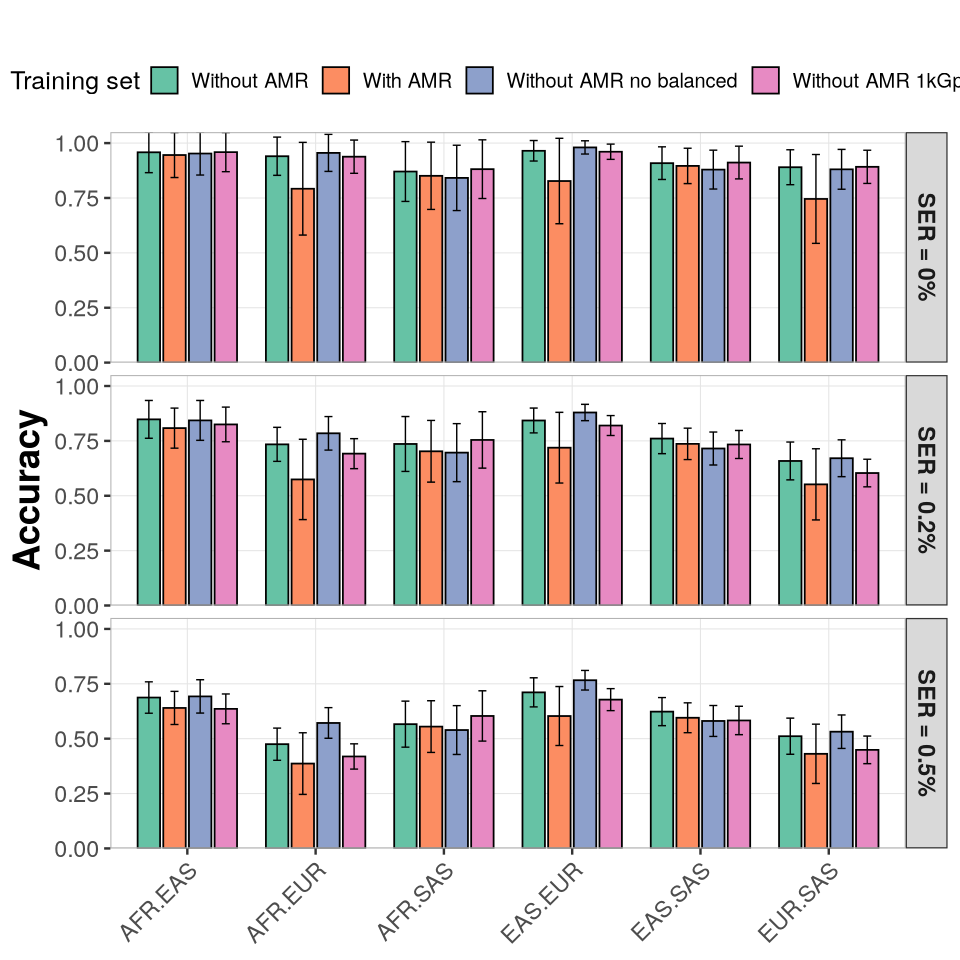

In [65]:

# ── Agrégation + plot ───────────────────────────────────────────────────────
bar_df <- bind_rows(
    accuracy_df_AMR    %>% filter(pop == "POP")        %>% mutate(training = "With AMR"),
    accuracy_df_no_AMR %>% filter(pop == "POP_no_AMR") %>% mutate(training = "Without AMR"),
    accuracy_df_no_AMR_no_balanced %>% filter(pop == "POP_no_balanced_no_AMR") %>% mutate(training = "Without AMR no balanced"),
    accuracy_df_no_AMR_1kGp_only %>% filter(pop == "POP_no_AMR") %>% mutate(training = "Without AMR 1kGp only")

  ) %>%
  filter(SE %in% c("SER = 0%", "SER = 0.2%", "SER = 0.5%")) %>%
  group_by(SE, comb, training) %>%
  summarise(mean_acc = mean(accuracy, na.rm = TRUE),
            sd_acc   = sd(accuracy,   na.rm = TRUE), .groups = "drop") %>%
  mutate(SE       = factor(SE, levels = c("SER = 0%", "SER = 0.2%", "SER = 0.5%")),
         training = factor(training, levels = c("Without AMR", "With AMR", "Without AMR no balanced","Without AMR 1kGp only")))
  

accuracy_plot <- ggplot(bar_df, aes(x = comb, y = mean_acc, fill = training)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8),
           color = "black", width = 0.7) +
  geom_errorbar(aes(ymin = pmax(mean_acc - sd_acc, 0),
                    ymax = pmin(mean_acc + sd_acc, 1.05)),
                position = position_dodge(width = 0.8), width = 0.25, linewidth = 0.4) +
  scale_y_continuous(limits = c(0, 1.05), expand = c(0, 0)) +
  scale_fill_brewer(palette = "Set2", name = "Training set") +
  facet_grid(SE ~ ., scales = "free_x", space = "free_x") +
  theme_bw(base_size = 15) +
  labs(y = "Accuracy", x = NULL, title = "") +
  theme(
    strip.text.x = element_text(size = 20, face = "bold"),
    strip.text.y = element_text(size = 14, face = "bold"),
    axis.text.x  = element_text(angle = 45, hjust = 1, size = 14),
    axis.text.y  = element_text(size = 14),
    axis.title.y = element_text(size = 22, face = "bold"),
    legend.position  = "top",
    panel.grid.major = element_line(color = "grey90", linewidth = 0.3),
    panel.grid.minor = element_blank(),
    panel.border     = element_rect(color = "grey70", linewidth = 0.6)
  )
accuracy_plot

#ggsave("/srv/home/mlef0011/Phasomix/output/figures/accuracy_local_ancestry_POP_AMR_effect.png", bar_df,width = 5, height = 5, dpi = 300)


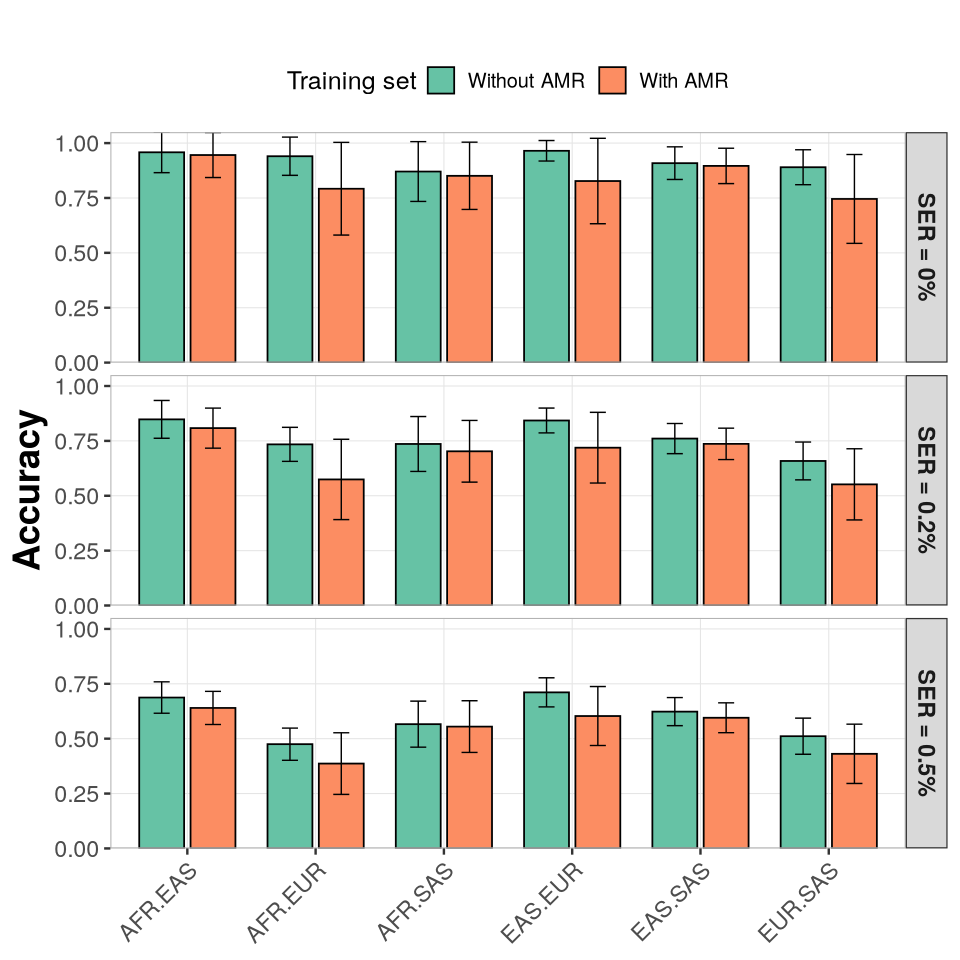

In [37]:

# ── Agrégation + plot ───────────────────────────────────────────────────────
bar_df <- bind_rows(
    accuracy_df_AMR    %>% filter(pop == "POP")        %>% mutate(training = "With AMR"),
    accuracy_df_no_AMR %>% filter(pop == "POP_no_AMR") %>% mutate(training = "Without AMR")
  ) %>%
  filter(SE %in% c("SER = 0%", "SER = 0.2%", "SER = 0.5%")) %>%
  group_by(SE, comb, training) %>%
  summarise(mean_acc = mean(accuracy, na.rm = TRUE),
            sd_acc   = sd(accuracy,   na.rm = TRUE), .groups = "drop") %>%
  mutate(SE       = factor(SE, levels = c("SER = 0%", "SER = 0.2%", "SER = 0.5%")),
         training = factor(training, levels = c("Without AMR", "With AMR")))
  

accuracy_plot <- ggplot(bar_df, aes(x = comb, y = mean_acc, fill = training)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8),
           color = "black", width = 0.7) +
  geom_errorbar(aes(ymin = pmax(mean_acc - sd_acc, 0),
                    ymax = pmin(mean_acc + sd_acc, 1.05)),
                position = position_dodge(width = 0.8), width = 0.25, linewidth = 0.4) +
  scale_y_continuous(limits = c(0, 1.05), expand = c(0, 0)) +
  scale_fill_brewer(palette = "Set2", name = "Training set") +
  facet_grid(SE ~ ., scales = "free_x", space = "free_x") +
  theme_bw(base_size = 15) +
  labs(y = "Accuracy", x = NULL, title = "") +
  theme(
    strip.text.x = element_text(size = 20, face = "bold"),
    strip.text.y = element_text(size = 14, face = "bold"),
    axis.text.x  = element_text(angle = 45, hjust = 1, size = 14),
    axis.text.y  = element_text(size = 14),
    axis.title.y = element_text(size = 22, face = "bold"),
    legend.position  = "top",
    panel.grid.major = element_line(color = "grey90", linewidth = 0.3),
    panel.grid.minor = element_blank(),
    panel.border     = element_rect(color = "grey70", linewidth = 0.6)
  )
accuracy_plot

ggsave("/srv/home/mlef0011/Phasomix/output/figures/accuracy_local_ancestry_POP_AMR_effect.png", accuracy_plot, width = 8, height = 6, dpi = 300)


In [19]:
bar_df

ERROR: Error: object 'bar_df' not found


In [11]:
library(dplyr)
library(ggplot2)
options(repr.plot.width = 16, repr.plot.height = 6)

for (se_val in unique(accuracy_df_no_AMR$SE)) {
    # ── Filtre à SER donné + renommage POP_no_AMR ─────────────────────────────
    plot_df <- accuracy_df_no_AMR %>%
      filter(SE == se_val) %>%
      mutate(pop = ifelse(pop == "POP_no_AMR", "POP (no AMR)", pop))

    # Ordre des facettes : POP (no AMR) en premier, puis les super-pops triées
    pop_levels <- c("POP (no AMR)", sort(setdiff(unique(plot_df$pop), "POP (no AMR)")))
    plot_df$pop <- factor(plot_df$pop, levels = pop_levels)

    # Ordre des paires par médiane décroissante
    ord <- plot_df %>%
      group_by(comb) %>%
      summarise(m = median(accuracy, na.rm = TRUE), .groups = "drop") %>%
      arrange(desc(m))
    plot_df$comb <- factor(plot_df$comb, levels = ord$comb)

    accuracy_plot <- ggplot(plot_df, aes(x = comb, y = accuracy, fill = pop)) +
      geom_boxplot(outlier.shape = NA, width = 0.7, linewidth = 0.4,
                   color = "grey20", alpha = 0.9) +
      geom_jitter(width = 0.15, height = 0, size = 0.6, alpha = 0.3, color = "grey25") +
      scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.25),
                         labels = scales::label_percent(accuracy = 1),
                         expand = expansion(mult = c(0.01, 0.02))) +
      scale_fill_brewer(palette = "Set2", name = "Super-population") +
      facet_grid(~ pop, scales = "free_x", space = "free_x") +
      theme_bw(base_size = 10) +
      labs(y = "Accuracy", x = NULL, title = "") +
      theme(
        strip.text.x     = element_text(size = 9, face = "bold"),
        axis.text.x      = element_text(angle = 45, hjust = 1, size = 7.5),
        axis.text.y      = element_text(size = 7.5),
        axis.title.y     = element_text(size = 9, face = "bold"),
        legend.position  = "none",
        panel.grid.major = element_line(color = "grey90", linewidth = 0.3),
        panel.grid.minor = element_blank(),
        panel.border     = element_rect(color = "grey70", linewidth = 0.6)
      )

    se_num <- as.numeric(gsub("SER = |%", "", se_val))

    ggsave(paste0("/srv/home/mlef0011/Phasomix/output/figures/accuracy_local_ancestry_SE_", se_num, ".png"),
           accuracy_plot, width = 12, height = 2, dpi = 300)
}

[1] "SER = 0%"   "SER = 0.1%" "SER = 0.2%" "SER = 0.5%" "SER = 1%"

In [14]:
se_val = unique(accuracy_df_no_AMR$SE)[1]

plot_df <- accuracy_df_no_AMR %>%
  filter(SE == se_val) %>%
  mutate(pop = ifelse(pop == "POP_no_AMR", "POP (no AMR)", pop))

# Ordre des facettes : POP (no AMR) en premier, puis les super-pops triées
pop_levels <- c("POP (no AMR)", sort(setdiff(unique(plot_df$pop), "POP (no AMR)")))
plot_df$pop <- factor(plot_df$pop, levels = pop_levels)

# Ordre des paires par médiane décroissante
ord <- plot_df %>%
  group_by(comb) %>%
  summarise(m = median(accuracy, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(m))
plot_df$comb <- factor(plot_df$comb, levels = ord$comb)

accuracy_plot <- ggplot(plot_df, aes(x = comb, y = accuracy, fill = pop)) +
  geom_boxplot(outlier.shape = NA, width = 0.7, linewidth = 0.4,
               color = "grey20", alpha = 0.9) +
  geom_jitter(width = 0.15, height = 0, size = 0.6, alpha = 0.3, color = "grey25") +
  scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.25),
                     labels = scales::label_percent(accuracy = 1),
                     expand = expansion(mult = c(0.01, 0.02))) +
  scale_fill_brewer(palette = "Set2", name = "Super-population") +
  facet_grid(~ pop, scales = "free_x", space = "free_x") +
  theme_bw(base_size = 10) +
  labs(y = "Accuracy", x = NULL, title = "") +
  theme(
    strip.text.x     = element_text(size = 9, face = "bold"),
    axis.text.x      = element_text(angle = 45, hjust = 1, size = 7.5),
    axis.text.y      = element_text(size = 7.5),
    axis.title.y     = element_text(size = 9, face = "bold"),
    legend.position  = "none",
    panel.grid.major = element_line(color = "grey90", linewidth = 0.3),
    panel.grid.minor = element_blank(),
    panel.border     = element_rect(color = "grey70", linewidth = 0.6)
  )

se_num <- as.numeric(gsub("SER = |%", "", se_val))

ggsave(paste0("/srv/home/mlef0011/Phasomix/output/figures/accuracy_local_ancestry_SE_", se_num, ".png"),
       accuracy_plot, width = 12, height = 2.5, dpi = 300)

In [38]:
summary(accuracy_df_no_AMR[accuracy_df_no_AMR$SE == "SER = 0%" & accuracy_df_no_AMR$pop == "POP_no_AMR" & accuracy_df_no_AMR$comb == "AFR.EUR",])
summary(accuracy_df_no_AMR[accuracy_df_no_AMR$SE == "SER = 0.2%" & accuracy_df_no_AMR$pop == "POP_no_AMR" & accuracy_df_no_AMR$comb == "AFR.EUR",])
summary(accuracy_df_no_AMR[accuracy_df_no_AMR$SE == "SER = 0.5%" & accuracy_df_no_AMR$pop == "POP_no_AMR" & accuracy_df_no_AMR$comb == "AFR.EUR",])

      SE                pop                comb            replicate        
 Length:100         Length:100         Length:100         Length:100        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
    accuracy     
 Min.   :0.4926  
 1st Qu.:0.9177  
 Median :0.9757  
 Mean   :0.9402  
 3rd Qu.:0.9973  
 Max.   :1.0000  

      SE                pop                comb            replicate        
 Length:100         Length:100         Length:100         Length:100        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
    accuracy     
 Min.   :0.4372  
 1st Qu.:0.6930  
 Median :0.7566  
 Mean   :0.7342  
 3rd Qu.:0.7858  
 Max.   :0.8624  

      SE                pop                comb            replicate        
 Length:100         Length:100         Length:100         Length:100        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
    accuracy     
 Min.   :0.2671  
 1st Qu.:0.4284  
 Median :0.4910  
 Mean   :0.4750  
 3rd Qu.:0.5297  
 Max.   :0.6070  

In [21]:
# moyenne par combinaison, pour un SE/pop donne (comme ton filtre)
aggregate(accuracy ~ comb,
          data = subset(accuracy_df_no_AMR, SE == "SER = 0.5%" & pop == "POP_no_AMR"),
          FUN = median, na.rm = TRUE)

aggregate(accuracy ~ comb,
          data = subset(accuracy_df_no_AMR, SE == "SER = 0%" & pop == "POP_no_AMR"),
          FUN = median, na.rm = TRUE)

comb,accuracy
<chr>,<dbl>
AFR.EAS,0.7047507
AFR.EUR,0.4910293
AFR.SAS,0.5803720
EAS.EUR,0.7307958
EAS.SAS,0.6297536
EUR.SAS,0.5261732


comb,accuracy
<chr>,<dbl>
AFR.EAS,1.0000000
AFR.EUR,0.9757075
AFR.SAS,0.9170007
EAS.EUR,0.9824554
EAS.SAS,0.9250982
EUR.SAS,0.9042000
